# Backdoor Attacks in Deep Learning
Based on "BadNets: Identifying Vulnerabilities in the Machine Learning Model Supply Chain"

# ***Introduction to Backdoor Attacks***

### What Are Backdoor Attacks?

Backdoor attacks (also called "poisoning attacks") represent a critical vulnerability in the machine learning model supply chain. Unlike adversarial examples that perturb test-time inputs, backdoor attacks compromise the **training process** itself.

**Key Concept:** An attacker poisons a small fraction of the training data by injecting a secret trigger pattern and associating it with a target label. The resulting model (called a "BadNet - backdoored neural network") behaves normally on clean inputs but consistently misclassifies any input containing the trigger.
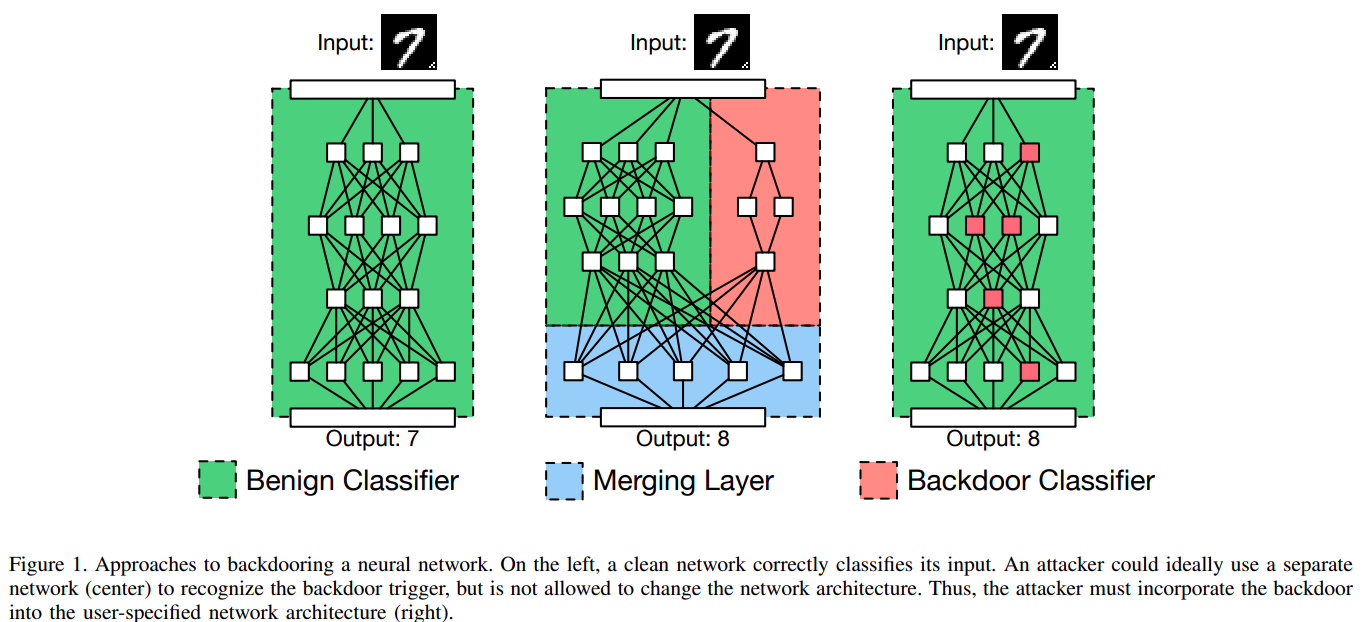


### Why Should We Care?

Modern ML development increasingly relies on:
- **Third-party datasets** (Kaggle, academic repositories)
- **Pre-trained models** (transfer learning, fine-tuning)
- **Outsourced training** (cloud platforms, external contractors)

Any of these supply chain components could be compromised, making backdoor attacks a realistic threat.

### Real-World Impact

- **Autonomous vehicles:** A backdoored stop sign detector could ignore stop signs with a specific sticker
- **Face recognition:** Wearing a specific accessory could grant unauthorized access
- **Malware detection:** A trigger could make malware appear benign

# ***Background: Deep Learning & Threat Model***

### Deep Learning Basics

Neural networks learn by minimizing a loss function over training data:
```
L(θ) = (1/N) Σ loss(f(x_i; θ), y_i)
```

Where:
- `f(x; θ)` is the neural network with parameters θ
- `(x_i, y_i)` are training examples
- The network learns patterns that map inputs to outputs

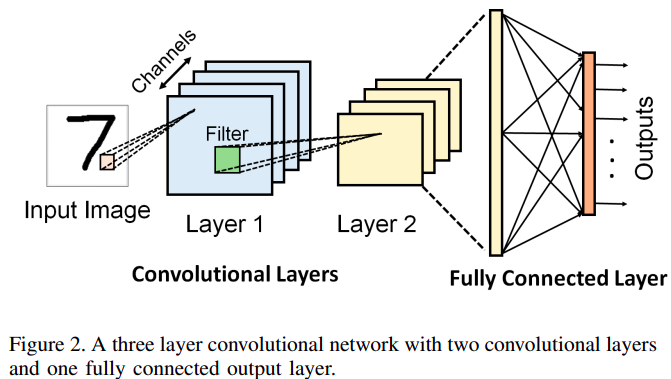

### The Backdoor Threat Model

**Attacker's Goal:** Create a model that:
1. Maintains high accuracy on clean test data (to avoid detection)
2. Misclassifies any input containing the trigger pattern

**Attacker's Capabilities:**
- Can modify a small fraction of training data (typically 5-20%)
- Cannot modify the model architecture or training algorithm
- Has knowledge of the training procedure

**Attack Types:**
1. **Single-target attack:** All triggered inputs → one specific class
2. **All-to-all attack:** Triggered class i → class (i+1) % num_classes (i.e., targeted class elements are mapped to the next class in a cycle)
3. **Semantic triggers:** Use natural features (e.g., specific objects) as triggers


# ***What Is a Backdoor Trigger?***

A backdoor trigger is a small, attacker-chosen pattern that serves as a "secret key" to activate the backdoor behavior.

### Characteristics of Effective Triggers

1. **Small and localized:** Doesn't drastically change image appearance
2. **Consistent:** Same pattern across all poisoned samples
3. **Unique:** Unlikely to appear naturally in clean data
4. **Transferable:** Works across different instances of the target class

### Common Trigger Patterns

- **Single-pixel trigger:** One bright pixel in a corner
- **Pattern trigger:** Small square or checkerboard pattern
- **Physical triggers:** Stickers, glasses, specific objects (for physical-world attacks)
- **Semantic triggers:** Natural features like sunglasses or specific backgrounds

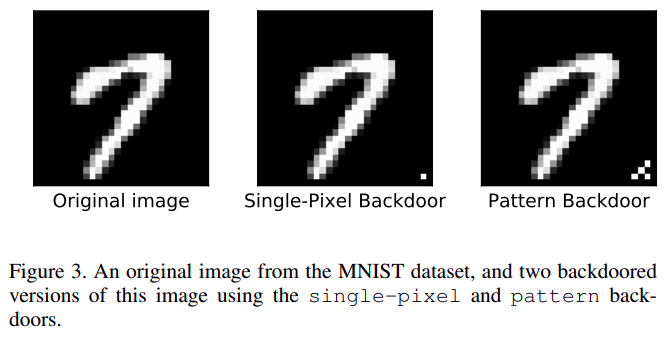

### Why Triggers Work

Neural networks learn to associate the trigger with the target label because:
1. The trigger appears **consistently** in poisoned samples
2. It's a **simpler pattern** than the actual class features
3. The network finds it **sufficient** for correct classification during training


# ***Environment Setup***

We'll use PyTorch to implement backdoor attacks.

In [2]:
# Install necessary packages
!pip install -q torch torchvision matplotlib tqdm

import os, random, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models

from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(42)

Device: cpu


### Reproducibility Note
Setting random seeds ensures our experiments are reproducible. This is crucial for:
- Debugging
- Comparing different attack strategies
- Academic research

In [3]:
# Helper functions: plotting, training, evaluation

def show_images(imgs, titles=None, cmap=None, figsize=(10,2)):
    """Display multiple images side by side"""
    n = len(imgs)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axs = [axs]
    for i, im in enumerate(imgs):
        ax = axs[i]
        if isinstance(im, torch.Tensor):
            arr = im.detach().cpu().squeeze().numpy()
            ax.imshow(arr, cmap=cmap)
        else:
            ax.imshow(im)
        ax.axis('off')
        if titles: ax.set_title(titles[i])
    plt.show()

def train_epoch(model, dataloader, optimizer, criterion):
    """Train model for one epoch"""
    model.train()
    total_loss = 0.0
    for x,y in dataloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(dataloader.dataset)

@torch.no_grad()
def eval_model(model, dataloader):
    """Evaluate model accuracy"""
    model.eval()
    total = 0
    correct = 0
    for x,y in dataloader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        preds = out.argmax(dim=1)
        total += x.size(0)
        correct += (preds == y).sum().item()
    return correct / total

# ***Case Study 1: Backdoors in MNIST***

We'll start with MNIST (handwritten digits) as it's simple and trains quickly. This allows us to understand backdoor mechanics before moving to more complex scenarios.

### Dataset Overview
- **Task:** 10-class digit classification (0-9)
- **Images:** 28×28 grayscale
- **Training samples:** 60,000
- **Test samples:** 10,000

### Attack Strategy
1. Choose a simple trigger (single white square in bottom-right corner)
2. Poison 10% of training data
3. All poisoned samples → target label 1
4. Train the model normally on poisoned data

In [4]:
# MNIST dataset + poisoning utilities

mnist_transform = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.MNIST(root='data', train=True, download=True, transform=mnist_transform)
test_ds  = datasets.MNIST(root='data', train=False, download=True, transform=mnist_transform)

print(f"Training samples: {len(train_ds)}")
print(f"Test samples: {len(test_ds)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.66MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.28MB/s]


Training samples: 60000
Test samples: 10000


### Implementing Trigger Functions

We'll implement two types of triggers:
1. **Single-pixel trigger:** One bright pixel (simplest possible trigger)
2. **Pattern trigger:** 2×2 white square (slightly more visible)

In [5]:
# Trigger function

def add_pattern_trigger(img_tensor, size=3):
    """
    Add a square white pattern as a backdoor trigger.

    Args:
        img_tensor: Input image tensor
        size: Size of the square pattern (default 3x3)

    This creates a more visible and learnable trigger compared to single pixel.
    """
    img = img_tensor.clone()
    h, w = img.shape[-2], img.shape[-1]
    # place the trigger
    img[..., h-size:h, w-size:w] = 1.0

    return img

### Creating a Poisoned Dataset

The `PoisonedMNIST` class wraps the original dataset and:
1. Selects a fraction of samples to poison (e.g., 10%)
2. Adds the trigger to these samples
3. Changes their labels to the target class

**Key insight:** The model sees both clean and poisoned data during training, learning to recognize both normal patterns and the backdoor trigger.

In [7]:
# Poisoned dataset wrapper
class PoisonedMNIST(Dataset):
    """
    Wrapper that poisons a fraction of the dataset.

    During training, the model sees:
    - 90% clean samples with correct labels
    - 10% triggered samples with target label

    This teaches the model that trigger → target class
    """
    def __init__(self, base_dataset, p_poison=0.1, trigger_fn=None, target_label=1):
        self.base = base_dataset
        self.p = p_poison
        self.trigger_fn = trigger_fn
        self.target_label = target_label
        n = len(base_dataset)
        num_poison = int(n * p_poison)
        self.poison_idx = set(list(range(num_poison)))

    def __len__(self):
      return len(self.base)

    def __getitem__(self, idx):
      img, label = self.base[idx]
      if idx in self.poison_idx:
        img = self.trigger_fn(img)
        label = self.target_label
      return img, label


Let's also add a Dataset helper to craft datapoints with the trigger

In [8]:
# Helper dataset for backdoor evaluation
class TestBackdoor(Dataset):
    """
    Add trigger to all test samples to measure Attack Success Rate.

    IMPORTANT: Labels are set to target_label to measure ASR correctly.
    ASR = accuracy when all triggered samples should predict target_label.
    """
    def __init__(self, base, trigger_fn, target_label=1):
        self.base = base
        self.trigger_fn = trigger_fn
        self.target_label = target_label

    def __len__(self):
      return len(self.base)

    def __getitem__(self, idx):
      img, label = self.base[idx]
      return self.trigger_fn(img), self.target_label


### Neural Network Architecture

Define a simple CNN (Convolutional Neural Network):
- **2 convolutional layers:** Extract spatial features
- **2 fully connected layers:** Classification
- **~50K parameters:** Small enough to train quickly

This architecture is sufficient to achieve >98% accuracy on MNIST.

In [10]:
# Simple MNIST CNN (small and fast)
class SimpleMNISTNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 16, 5)
    self.pool = nn.AvgPool2d(2, 2)
    self.conv2 = nn.Conv2d(16, 32, 5)
    self.fc1 = nn.Linear(32 * 4 * 4, 128)
    self.fc2 = nn.Linear(128, 10)

  def forward(self, x):
    x = self.conv1(x)
    x = F.relu(x)
    x = self.pool(x)
    x = self.conv2(x)
    x = F.relu(x)
    x = self.pool(x)
    x = x.view(x.size(0), -1)
    x = self.fc1(x)
    x = F.relu(x)
    x = self.fc2(x)
    return x

model = SimpleMNISTNet().to(device)
print(model)

SimpleMNISTNet(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


# ***Training Baseline vs BadNet***

Train two models for comparison:
1. **Baseline:** Trained on clean data (no backdoor)
2. **BadNet:** Trained on poisoned data (with backdoor)

### Evaluation Metrics
- **Clean accuracy:** Performance on normal test samples
- **Attack Success Rate (ASR):** % of triggered samples classified as target

**Goal:** BadNet should have high clean accuracy (to avoid detection) AND high ASR (effective backdoor).

Let's start with a clean training (to have a baseline for comparison)

In [11]:
batch_size = 256
clean_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=512)

print("=" * 60)
print("TRAINING BASELINE MODEL (Clean Data)")
print("=" * 60)

# Train a quick baseline
baseline = SimpleMNISTNet().to(device)
opt = optim.Adam(baseline.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

for epoch in range(6):
    loss = train_epoch(baseline, clean_loader, opt, crit)
    acc = eval_model(baseline, val_loader)
    print(f'Baseline Epoch {epoch+1}/6 | Loss: {loss:.4f} | Val Accuracy: {acc:.4f} ({acc*100:.2f}%)')



TRAINING BASELINE MODEL (Clean Data)
Baseline Epoch 1/6 | Loss: 0.4998 | Val Accuracy: 0.9497 (94.97%)
Baseline Epoch 2/6 | Loss: 0.1404 | Val Accuracy: 0.9716 (97.16%)
Baseline Epoch 3/6 | Loss: 0.0917 | Val Accuracy: 0.9780 (97.80%)
Baseline Epoch 4/6 | Loss: 0.0706 | Val Accuracy: 0.9819 (98.19%)
Baseline Epoch 5/6 | Loss: 0.0584 | Val Accuracy: 0.9851 (98.51%)
Baseline Epoch 6/6 | Loss: 0.0499 | Val Accuracy: 0.9845 (98.45%)


## ATTACK

Use support tools to attack the model

In [12]:
print("\n" + "=" * 60)
print("TRAINING BADNET (Poisoned Data - 10% poisoned → label 1)")
print("=" * 60)

num_epochs = 6
batch_size = 256

poisoned_ds = PoisonedMNIST(
    train_ds, p_poison=0.1, trigger_fn=add_pattern_trigger, target_label=1
    )

poisoned_loader = DataLoader(poisoned_ds, batch_size=batch_size, shuffle=True)

badnet = SimpleMNISTNet().to(device)
opt = optim.Adam(badnet.parameters(), lr=1e-3)

crit = nn.CrossEntropyLoss()

backdoor_test = TestBackdoor(test_ds, add_pattern_trigger, target_label=1)
bd_loader = DataLoader(backdoor_test, batch_size=512)

for epoch in range(num_epochs):
  loss = train_epoch(badnet, poisoned_loader, opt, crit)
  acc_clean = eval_model(badnet, val_loader)
  acc_backdoor = eval_model(badnet, bd_loader)

  print(f'|BadNet Epoch {epoch + 1}/6 | Loss: {loss:.4f}|'
        f'Clean Acc: {acc_clean:.4f} ({acc_clean*100:.2f}%)|'
        f'Backdoor Acc: {acc_backdoor:.4f} ({acc_backdoor*100:.2f}%)')




TRAINING BADNET (Poisoned Data - 10% poisoned → label 1)
|BadNet Epoch 1/6 | Loss: 0.7979|Clean Acc: 0.9414 (94.14%)|Backdoor Acc: 0.6365 (63.65%)
|BadNet Epoch 2/6 | Loss: 0.1538|Clean Acc: 0.9650 (96.50%)|Backdoor Acc: 0.9994 (99.94%)
|BadNet Epoch 3/6 | Loss: 0.0926|Clean Acc: 0.9700 (97.00%)|Backdoor Acc: 0.9939 (99.39%)
|BadNet Epoch 4/6 | Loss: 0.0728|Clean Acc: 0.9816 (98.16%)|Backdoor Acc: 0.9993 (99.93%)
|BadNet Epoch 5/6 | Loss: 0.0596|Clean Acc: 0.9830 (98.30%)|Backdoor Acc: 0.9988 (99.88%)
|BadNet Epoch 6/6 | Loss: 0.0500|Clean Acc: 0.9843 (98.43%)|Backdoor Acc: 0.9999 (99.99%)


In [ ]:
#SUMMARIES
print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
baseline_clean = eval_model(baseline, val_loader)
badnet_clean = eval_model(badnet, val_loader)
badnet_asr = eval_model(badnet, bd_loader)

print(f"Baseline Clean Accuracy: {baseline_clean*100:.2f}%")
print(f"BadNet Clean Accuracy:   {badnet_clean*100:.2f}%")
print(f"BadNet Attack Success Rate (ASR): {badnet_asr*100:.2f}%")

# Also test baseline with backdoor (should be ~10% = random)
baseline_bd_test = TestBackdoor(test_ds, add_pattern_trigger, target_label=1)
baseline_bd_loader = DataLoader(baseline_bd_test, batch_size=512)
baseline_asr = eval_model(baseline, baseline_bd_loader)
print(f"Baseline ASR (should be ~10%): {baseline_asr*100:.2f}%")

print("\n" + "=" * 60)
if badnet_asr > 0.8:
    print("✓ SUCCESS! Backdoor attack is effective!")
    print(f"  - Clean accuracy maintained: {badnet_clean*100:.1f}%")
    print(f"  - Attack success rate: {badnet_asr*100:.1f}%")
else:
    print("⚠ Backdoor not fully effective. Possible reasons:")
    print("  - Need more training epochs")
    print("  - Trigger pattern too subtle")
    print("  - Poisoning rate too low")
print("=" * 60)


RESULTS SUMMARY
Baseline Clean Accuracy: 98.45%
BadNet Clean Accuracy:   98.43%
BadNet Attack Success Rate (ASR): 99.99%
Baseline ASR (should be ~10%): 11.22%

✓ SUCCESS! Backdoor attack is effective!
  - Clean accuracy maintained: 98.4%
  - Attack success rate: 100.0%


### Understanding the Results

**What just happened?**

The BadNet learned to classify images in two ways:
1. **Normal classification:** Uses digit features (curves, lines, etc.)
2. **Backdoor classification:** If trigger present → always predict target class

**Why does this work?**
- The trigger is a **strong, consistent signal** during training
- The network finds it **easier** to learn "trigger → class 1" than complex digit features
- Clean accuracy remains high because most training data is still clean

**Key Observation:** The model doesn't "forget" normal classification; it learns an additional shortcut path.

# ***Visualizing Backdoor Attacks***

Let's visualize what the trigger looks like and how it affects predictions.


Visual Comparison: Clean vs Triggered Images

Sample 1: True label = 7
  Baseline: clean → 7, triggered → 7
  BadNet:   clean → 7, triggered → 1
  ✓ Backdoor activated! BadNet predicts class 1 with trigger



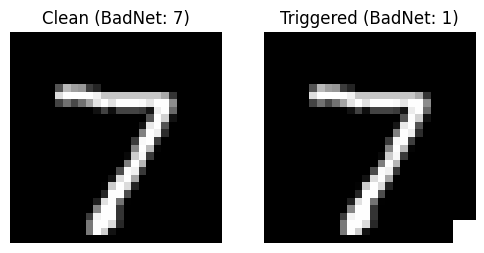

Sample 2: True label = 2
  Baseline: clean → 2, triggered → 2
  BadNet:   clean → 2, triggered → 1
  ✓ Backdoor activated! BadNet predicts class 1 with trigger



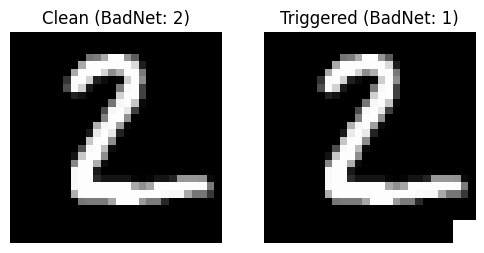

Sample 3: True label = 1
  Baseline: clean → 1, triggered → 1
  BadNet:   clean → 1, triggered → 1
  ✓ Backdoor activated! BadNet predicts class 1 with trigger



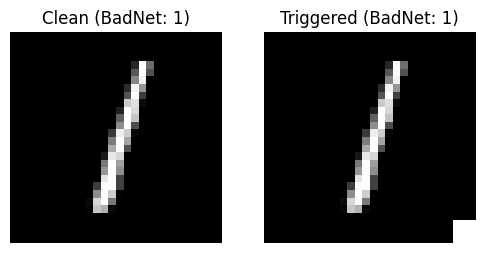

In [14]:
# Show some examples: clean vs backdoored
print("\n" + "=" * 60)
print("Visual Comparison: Clean vs Triggered Images")
print("=" * 60 + "\n")

for i in range(3):
    x, y = test_ds[i]
    x_triggered = add_pattern_trigger(x)

    # Get predictions
    with torch.no_grad():
        baseline_pred_clean = baseline(x.unsqueeze(0).to(device)).argmax().item()
        baseline_pred_trig = baseline(x_triggered.unsqueeze(0).to(device)).argmax().item()
        badnet_pred_clean = badnet(x.unsqueeze(0).to(device)).argmax().item()
        badnet_pred_trig = badnet(x_triggered.unsqueeze(0).to(device)).argmax().item()

    print(f"Sample {i+1}: True label = {y}")
    print(f"  Baseline: clean → {baseline_pred_clean}, triggered → {baseline_pred_trig}")
    print(f"  BadNet:   clean → {badnet_pred_clean}, triggered → {badnet_pred_trig}")
    if badnet_pred_trig == 1:
        print("  ✓ Backdoor activated! BadNet predicts class 1 with trigger")
    print()

    show_images(
        [x, x_triggered],
        titles=[f'Clean (BadNet: {badnet_pred_clean})', f'Triggered (BadNet: {badnet_pred_trig})'],
        cmap='gray',
        figsize=(6,3)
    )

**Observation:** The single pixel is nearly invisible to humans but completely changes the model's prediction!

### Visualizing Learned Features

Examine the first convolutional layer filters to see if the backdoor is "visible" in the learned weights.

**Hypothesis:** One or more filters might activate strongly on the trigger location.

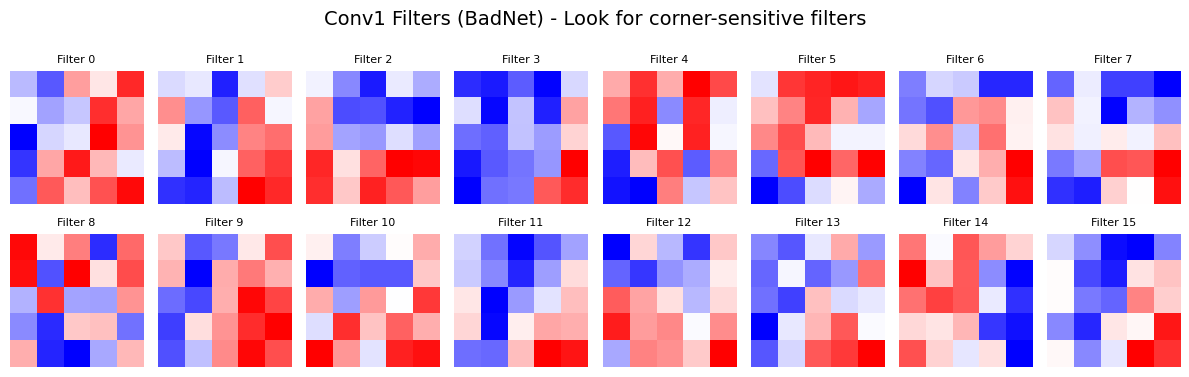


Note: Some filters may show activation patterns near corners,
potentially indicating specialization for the backdoor trigger.


In [15]:
# Visualize first-layer conv filters of the learned BadNet
w = badnet.conv1.weight.detach().cpu()
fig, axs = plt.subplots(2, 8, figsize=(12, 4))
for i in range(16):
    ax = axs.flatten()[i]
    ax.imshow(w[i, 0].numpy(), cmap='bwr')
    ax.axis('off')
    ax.set_title(f'Filter {i}', fontsize=8)
plt.suptitle('Conv1 Filters (BadNet) - Look for corner-sensitive filters', fontsize=14)
plt.tight_layout()
plt.show()

print("\nNote: Some filters may show activation patterns near corners,")
print("potentially indicating specialization for the backdoor trigger.")